## **Preprocessing**

**Step 1: Load data raw**

In [ ]:
# Upload data hasil scraping
from google.colab import files
uploaded = files.upload()

Saving skincare-raw.xlsx to skincare-raw.xlsx


In [ ]:
import pandas as pd

data = pd.read_excel("skincare-raw.xlsx")
data.head()

,type,id,url,twitterUrl,text,source,retweetCount,replyCount,likeCount,quoteCount,...,card,place,entities,reply_to_user_results,quoted_tweet_results,quoted_tweet,retweeted_tweet,isConversationControlled,searchTermIndex,isQuote
0,tweet,1762525655508325120,https://x.com/BebbieSari/status/17625256555083...,https://twitter.com/BebbieSari/status/17625256...,Rejuvenate & transform your skin with these e...,NaN,0,0,1,0,...,NaN,{},"{'hashtags': [{'indices': [130, 139], 'text': ...",NaN,NaN,NaN,NaN,False,0,NaN
1,tweet,1762508905144558080,https://x.com/7chillchoigf/status/176250890514...,https://twitter.com/7chillchoigf/status/176250...,"Keknya skinker/? Ini sama kayak disini, dia ma...",NaN,0,1,0,0,...,NaN,{},"{'hashtags': [], 'symbols': [], 'timestamps': ...",NaN,NaN,"{'type': 'tweet', 'id': '1762353655980937218',...",NaN,False,0,1.0
2,tweet,1762499074828402944,https://x.com/Kiarulan180114/status/1762499074...,https://twitter.com/Kiarulan180114/status/1762...,Tuhkan emang skincare ini bagus banget buat ny...,NaN,0,0,0,0,...,NaN,{},"{'hashtags': [], 'symbols': [], 'timestamps': ...",NaN,NaN,NaN,NaN,False,0,NaN
3,tweet,1762487216809337088,https://x.com/mangkokucing/status/176248721680...,https://twitter.com/mangkokucing/status/176248...,Btw skintype aku oily acne prone. Dari dulu ka...,NaN,0,0,0,0,...,NaN,{},"{'hashtags': [], 'symbols': [], 'timestamps': ...",NaN,NaN,NaN,NaN,False,0,NaN
4,tweet,1762445590905191936,https://x.com/aqilanp29/status/176244559090519...,https://twitter.com/aqilanp29/status/176244559...,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...",NaN,0,0,0,0,...,NaN,{},"{'hashtags': [], 'symbols': [], 'timestamps': ...",NaN,NaN,NaN,NaN,False,0,NaN


In [ ]:
# Ambil hanya kolom 'text', karena analisis sentimen fokus ke isi tweet
data = data[['text']]

# Menghapus tweet kosong (NaN)
data.dropna(inplace=True)

print("Jumlah data awal:", len(data))
data.head(15)

Jumlah data awal: 3526


,text
0,Rejuvenate & transform your skin with these e...
1,"Keknya skinker/? Ini sama kayak disini, dia ma..."
2,Tuhkan emang skincare ini bagus banget buat ny...
3,Btw skintype aku oily acne prone. Dari dulu ka...
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu..."
5,Gw tuh lagi bingung ya.. Skincare jenis apa la...
6,Kalian ada yg suka pake masker wajah gak? Skin...
7,"Sejak saat itu, aku mulai make *my own comfort..."
8,"Beras itu semua butuh, dan itu makanan pokok, ..."
9,@NenkMonica @KangDedyMulyadi Skincare per 2/3 ...


**Step 2: Cleaning dan case folding**

In [ ]:
import re

def clean_text (text):
  # Menghapus Username twitter
  text=re.sub(r'@[^\s]+','',text)
  # Menghapus URL/link
  text=re.sub(r'(?:@|http?://|https?://|www)\S+', '', text)
  # Menghapus simbol hashtag tetapi mempertahankan katanya
  text=re.sub(r'#', '', text)
  # Menghapus tag html
  text=re.sub('<.*?>', '', text)
  # Mengganti line baru dengan spasi
  text=re.sub("\n"," ",text)
  # Mengubah ke huruf kecil
  text=text.lower()
  # Menghapus single character
  text=re.sub(r"\b[a-zA-Z]\b", "", text)
  # Menghapus simbol/tanda baca yang tidak penting
  text=re.sub(r'["$%^&*()_+=|~`{}\[\]:;<>/\\]', ' ', text)
  # Merapikan spasi pada teks
  text=' '.join(text.split())
  return text

data['clean_text'] = data['text'].apply(clean_text)
data.head()

,text,clean_text
0,Rejuvenate & transform your skin with these e...,rejuvenate transform your skin with these effe...
1,"Keknya skinker/? Ini sama kayak disini, dia ma...","keknya skinker ? ini sama kayak disini, dia ma..."
2,Tuhkan emang skincare ini bagus banget buat ny...,tuhkan emang skincare ini bagus banget buat ny...
3,Btw skintype aku oily acne prone. Dari dulu ka...,btw skintype aku oily acne prone. dari dulu ka...
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...","bener sekaliiiii, sebagus ituuu, pake yang ijo..."


**Step 3: Filtering**

In [ ]:
# Menghapus tweet duplikat
data.drop_duplicates(subset='clean_text', inplace=True)

print("Jumlah data setelah filtering duplikat data:", len(data))

Jumlah data setelah filtering duplikat data: 2844


In [ ]:
# Hanya ambil tweet yang punya ≥ 3 kata
data = data[data['clean_text'].str.split().str.len() >= 3]

print("Jumlah data setelah filtering 3 kata:", len(data))

Jumlah data setelah filtering 3 kata: 2837


**Step 4: Tokenizing**

In [ ]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

data['tokenized_text'] = data['clean_text'].apply(word_tokenize)
data.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,clean_text,tokenized_text
0,Rejuvenate & transform your skin with these e...,rejuvenate transform your skin with these effe...,"[rejuvenate, transform, your, skin, with, thes..."
1,"Keknya skinker/? Ini sama kayak disini, dia ma...","keknya skinker ? ini sama kayak disini, dia ma...","[keknya, skinker, ?, ini, sama, kayak, disini,..."
2,Tuhkan emang skincare ini bagus banget buat ny...,tuhkan emang skincare ini bagus banget buat ny...,"[tuhkan, emang, skincare, ini, bagus, banget, ..."
3,Btw skintype aku oily acne prone. Dari dulu ka...,btw skintype aku oily acne prone. dari dulu ka...,"[btw, skintype, aku, oily, acne, prone, ., dar..."
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...","bener sekaliiiii, sebagus ituuu, pake yang ijo...","[bener, sekaliiiii, ,, sebagus, ituuu, ,, pake..."


**Step 5: Normalizing**

In [ ]:
def normalisasi1_text(list_kata):
  # Mengubah kata berulang ("bagussss" menjadi "bagus")
  return [re.sub(r'(.)\1{2,}', r'\1', kata) for kata in list_kata]

data['normalized_text'] = data['tokenized_text'].apply(normalisasi1_text)
data.head()

,text,clean_text,tokenized_text,normalized_text
0,Rejuvenate & transform your skin with these e...,rejuvenate transform your skin with these effe...,"[rejuvenate, transform, your, skin, with, thes...","[rejuvenate, transform, your, skin, with, thes..."
1,"Keknya skinker/? Ini sama kayak disini, dia ma...","keknya skinker ? ini sama kayak disini, dia ma...","[keknya, skinker, ?, ini, sama, kayak, disini,...","[keknya, skinker, ?, ini, sama, kayak, disini,..."
2,Tuhkan emang skincare ini bagus banget buat ny...,tuhkan emang skincare ini bagus banget buat ny...,"[tuhkan, emang, skincare, ini, bagus, banget, ...","[tuhkan, emang, skincare, ini, bagus, banget, ..."
3,Btw skintype aku oily acne prone. Dari dulu ka...,btw skintype aku oily acne prone. dari dulu ka...,"[btw, skintype, aku, oily, acne, prone, ., dar...","[btw, skintype, aku, oily, acne, prone, ., dar..."
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...","bener sekaliiiii, sebagus ituuu, pake yang ijo...","[bener, sekaliiiii, ,, sebagus, ituuu, ,, pake...","[bener, sekali, ,, sebagus, itu, ,, pake, yang..."


In [ ]:
# Colloquial Indonesian Lexicon (2018)
kamus_alay = pd.read_csv('https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv')
kamus_alay = kamus_alay.filter(['slang', 'formal'], axis=1)
kamus_alay = kamus_alay.drop_duplicates(subset=['slang'], keep='first')
kamus_alay = kamus_alay.set_index('slang')

kamus_dict = kamus_alay['formal'].to_dict()

In [ ]:
# Penambahan kamus secara mandiri
custom_dict = {
    'co': 'checkout',
    'po': 'preorder',
    'bo': 'breakout',
    'flashsale': 'flash sale',
    'soldout': 'sold out',
    'restok': 'restock',
    'teksturx': 'teksturnya',
    'wangy': 'wangi',
    'lembabin': 'melembapkan',
    'ngelembabin': 'melembapkan',
    'nyerep': 'menyerap',
    'berlu': 'perlu',
    'st': 'skin type',
    'skintype': 'skin type',
    'fw': 'face wash',
    'moist': 'moisturizer',
    'mw': 'micellar water',
    'skinker': 'skincare',
    'mehong': 'mahal',
    'emejing': 'amazing',
    'mantul': 'mantap betul',
    'kalo': 'kalau',
    'tbh': 'to be honest'
}

# Menggabungkan dengan kamus CIL
kamus_final = {**kamus_dict, **custom_dict}

In [ ]:
def normalisasi2_text(list_kata):
    return [kamus_final.get(word, word) for word in list_kata]

data['normalized_text'] = data['normalized_text'].apply(normalisasi2_text)

# Menggabungkan kembali list kata menjadi satu kalimat utuh (string)
data['normalized_text'] = data['normalized_text'].apply(lambda x: ' '.join(x))
data.head()

,text,clean_text,tokenized_text,normalized_text
0,Rejuvenate & transform your skin with these e...,rejuvenate transform your skin with these effe...,"[rejuvenate, transform, your, skin, with, thes...",rejuvenate transform your skin with these effe...
1,"Keknya skinker/? Ini sama kayak disini, dia ma...","keknya skinker ? ini sama kayak disini, dia ma...","[keknya, skinker, ?, ini, sama, kayak, disini,...","kayaknya skincare ? ini sama kayak disini , di..."
2,Tuhkan emang skincare ini bagus banget buat ny...,tuhkan emang skincare ini bagus banget buat ny...,"[tuhkan, emang, skincare, ini, bagus, banget, ...",tuhkan memang skincare ini bagus banget buat n...
3,Btw skintype aku oily acne prone. Dari dulu ka...,btw skintype aku oily acne prone. dari dulu ka...,"[btw, skintype, aku, oily, acne, prone, ., dar...",btw skin type aku oily acne prone . dari dulu ...
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...","bener sekaliiiii, sebagus ituuu, pake yang ijo...","[bener, sekaliiiii, ,, sebagus, ituuu, ,, pake...","benar sekali , sebagus itu , pakai yang ijo je..."


**Step 6: Simpan hasil preprocessing**

In [ ]:
# Menyimpan hasil preprocessing data raw dalam format excel untuk diberi label manual
data.to_excel('skincare-cleaned.xlsx', index=False)

## **Cohen's Kappa**

In [ ]:
# Upload data yang sudah diberi label secara manual oleh 2 annotators
from google.colab import files
uploaded = files.upload()

Saving skincare-labeled1.xlsx to skincare-labeled1.xlsx
Saving skincare-labeled2.xlsx to skincare-labeled2.xlsx


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

annotator1 = pd.read_excel('skincare-labeled1.xlsx')
annotator2 = pd.read_excel('skincare-labeled2.xlsx')

label_a1 = annotator1['label']
label_a2 = annotator2['label']

# Hitung skor Kappa
kappa_score = cohen_kappa_score(label_a1, label_a2)

print(f"Nilai Cohen's Kappa: {kappa_score:.4f}")

Nilai Cohen's Kappa: 0.7836


label
Neutral     1974
Positive     568
Negative     295
Name: count, dtype: int64


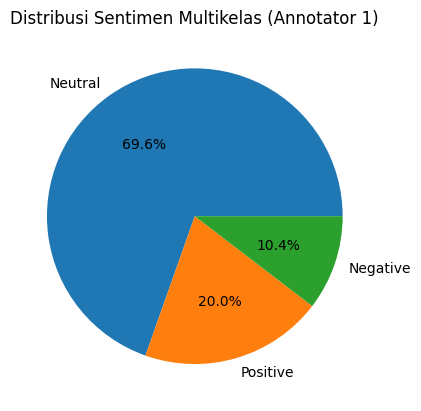

In [ ]:
import matplotlib.pyplot as plt

label_map = {0: 'Positive', 1: 'Neutral', 2: 'Negative'}

# 1. Tampilkan jumlah angkanya dulu
print(annotator1['label'].map(label_map).value_counts())

# 2. Baru buat dan tampilkan grafiknya
annotator1['label'].map(label_map).value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribusi Sentimen Multikelas (Annotator 1)'
)
plt.ylabel('')
plt.show()

label
Neutral     1885
Positive     558
Negative     394
Name: count, dtype: int64


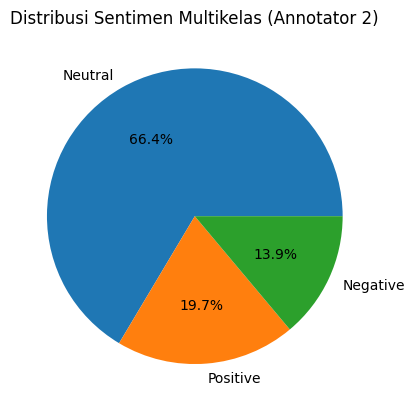

In [ ]:
import matplotlib.pyplot as plt

label_map = {0: 'Positive', 1: 'Neutral', 2: 'Negative'}

# 1. Tampilkan jumlah angkanya dulu
print(annotator2['label'].map(label_map).value_counts())

# 2. Baru buat dan tampilkan grafiknya
annotator2['label'].map(label_map).value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribusi Sentimen Multikelas (Annotator 2)'
)
plt.ylabel('')
plt.show()

## **Exploratory Data Analysis**

In [ ]:
# Upload data yang sudah diberi label
from google.colab import files
uploaded = files.upload()

Saving skincare-labeled.xlsx to skincare-labeled.xlsx


In [ ]:
import pandas as pd

data = pd.read_excel('skincare-labeled.xlsx')

label = data['label']

label
Neutral     1927
Positive     565
Negative     345
Name: count, dtype: int64


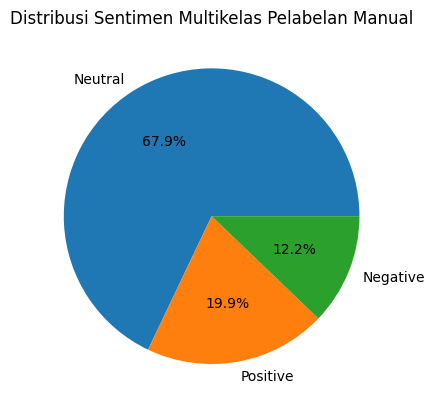

In [ ]:
import matplotlib.pyplot as plt

label_map = {0: 'Positive', 1: 'Neutral', 2: 'Negative'}

# 1. Tampilkan jumlah angkanya dulu
print(data['label'].map(label_map).value_counts())

# 2. Baru buat dan tampilkan grafiknya
data['label'].map(label_map).value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribusi Sentimen Multikelas Pelabelan Manual'
)
plt.ylabel('')
plt.show()

label
Neutral     1927
Positive     565
Negative     345
Name: count, dtype: int64


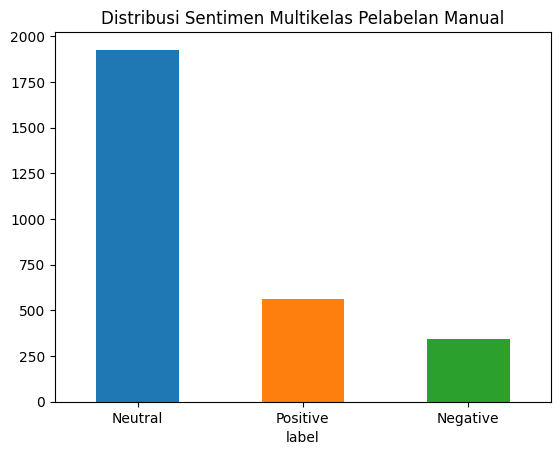

In [ ]:
import matplotlib.pyplot as plt

label_map = {0: 'Positive', 1: 'Neutral', 2: 'Negative'}

# 1. Tampilkan jumlah angkanya dulu
print(data['label'].map(label_map).value_counts())

# 2. Baru buat dan tampilkan grafiknya
data['label'].map(label_map).value_counts().plot(
    kind='bar',
    title='Distribusi Sentimen Multikelas Pelabelan Manual',
    color=['#1f77b4', '#ff7f0e', '#2ca02c'],
    rot=0
)
plt.ylabel('')
plt.show()